<a href="https://colab.research.google.com/github/saranya-45/machine-learning/blob/main/LSTMand%20RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0213
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0097 
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0073 
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0070 
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0072 
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0051 
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0059 
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0052 
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0059 
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055 
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0057 
Epoch 13/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0049 
Epoch 14/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 
Epoch 15/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0049 
Epoch 16/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

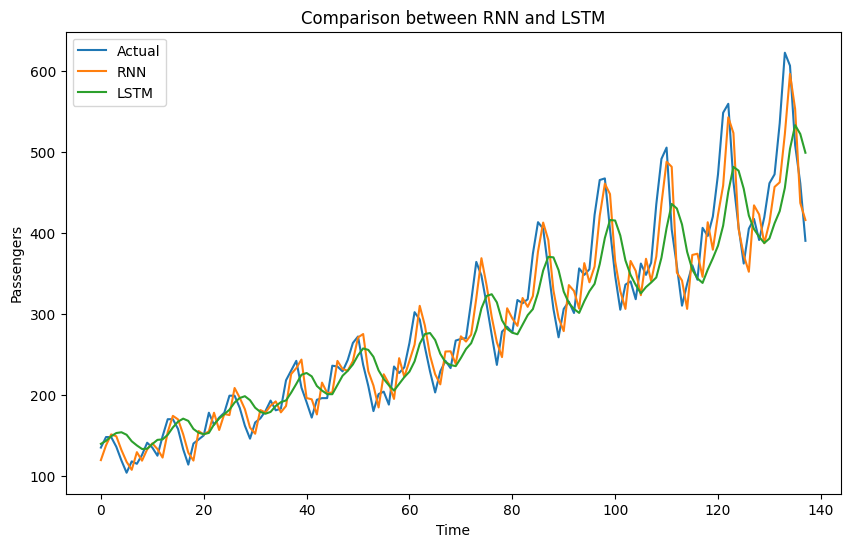

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense
import matplotlib.pyplot as plt

# Load dataset
dataset = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")

data = dataset['Passengers'].values
data = data.reshape(-1,1)

# Scaling
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

# Create time series dataset
time_step = 5
x = []
y = []

for i in range(len(data_scaled) - time_step - 1):
    x.append(data_scaled[i:(i+time_step), 0])
    y.append(data_scaled[i+time_step, 0])

x = np.array(x)
y = np.array(y)

# reshape for RNN/LSTM
x = x.reshape(x.shape[0], x.shape[1], 1)

# ---------------- RNN MODEL ----------------
rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, activation="tanh", input_shape=(time_step,1)))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam', loss='mean_squared_error')

rnn_model.fit(x, y, epochs=50, batch_size=16)

# RNN predictions
rnn_predictions = rnn_model.predict(x)

# ---------------- LSTM MODEL ----------------
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation="tanh", input_shape=(time_step,1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

lstm_model.fit(x, y, epochs=50, batch_size=16)

# LSTM predictions
lstm_predictions = lstm_model.predict(x)

# Inverse scaling
rnn_predictions = scaler.inverse_transform(rnn_predictions)
lstm_predictions = scaler.inverse_transform(lstm_predictions)
y_actual = scaler.inverse_transform(y.reshape(-1,1))

# ---------------- GRAPH ----------------
plt.figure(figsize=(10,6))

plt.plot(y_actual, label="Actual")
plt.plot(rnn_predictions, label="RNN")
plt.plot(lstm_predictions, label="LSTM")

plt.title("Comparison between RNN and LSTM")
plt.xlabel("Time")
plt.ylabel("Passengers")

plt.legend()
plt.show()